# Etapa 1 — Visualização dos resultados
Este notebook **só lê** o que o `etapa1.py` já gerou (CSVs e imagens). Para atualizar os resultados, rode `python etapa1.py` na raiz e depois execute as células de novo (*Run All*).

In [1]:
from pathlib import Path
import textwrap
import pandas as pd
from IPython.display import Image, display, Markdown

# Funciona tanto com o notebook em notebooks/ quanto na raiz do projeto
RAIZ = Path.cwd() if (Path.cwd() / "etapa1.py").exists() else Path.cwd().parent
ASSETS = RAIZ / "relatorio" / "assets"
TABELAS = RAIZ / "relatorio" / "tabelas"
CSV_SENTIMENTO = RAIZ / "dados" / "processados" / "comentarios_sentimento.csv"
CSV_LIMPOS = RAIZ / "dados" / "intermediarios" / "comentarios_limpos.csv"

if not CSV_SENTIMENTO.exists():
    raise FileNotFoundError("Rode `python etapa1.py` na raiz do projeto antes de abrir este notebook.")

pd.set_option("display.max_colwidth", 140)
pd.set_option("display.width", 160)
df = pd.read_csv(CSV_SENTIMENTO)
limpos = pd.read_csv(CSV_LIMPOS)
metodo = df["metodo_sentimento"].iloc[0]
print(f"{len(df)} comentários classificados de {df['video_id'].nunique()} vídeo(s) | método: {metodo}")
if metodo != "pysentimiento":
    print("ATENÇÃO: o pysentimiento não foi usado (léxico de reserva). Não apresente estes resultados como finais.")

20 comentários classificados de 2 vídeo(s) | método: lexico_reserva
ATENÇÃO: o pysentimiento não foi usado (léxico de reserva). Não apresente estes resultados como finais.


## 1. Visão geral da base
Quantos comentários entraram, quantos ficaram de fora e por quê (idioma ou texto vazio).

In [2]:
visao = pd.DataFrame({
    "coletados": limpos.groupby("video_id").size(),
    "classificados": df.groupby("video_id").size(),
}).fillna(0).astype(int)
visao["fora do recorte"] = visao["coletados"] - visao["classificados"]
visao["principais"] = df[df.tipo == "principal"].groupby("video_id").size()
visao["respostas"] = df[df.tipo == "resposta"].groupby("video_id").size()
display(visao.fillna(0).astype(int))
print("Idiomas detectados (todos os coletados):", limpos["idioma"].value_counts().to_dict())

,coletados,classificados,fora do recorte,principais,respostas
video_id,,,,,
SIMULADO0001,12,10,2,7,3
SIMULADO0002,10,10,0,8,2


Idiomas detectados (todos os coletados): {'pt': 17, 'indefinido': 3, 'es': 1, 'en': 1}


## 2. Sentimento por vídeo
Proporções com intervalo de confiança de 95% (Wilson). **Intervalos que se sobrepõem = não dá para dizer que os vídeos diferem.**

,vídeo,n,positivo,neutro,negativo,score médio
0,Vídeo simulado A,10,40% [17–69],40% [17–69],20% [6–51],0.14
1,Vídeo simulado B,10,50% [24–76],30% [11–60],20% [6–51],0.21


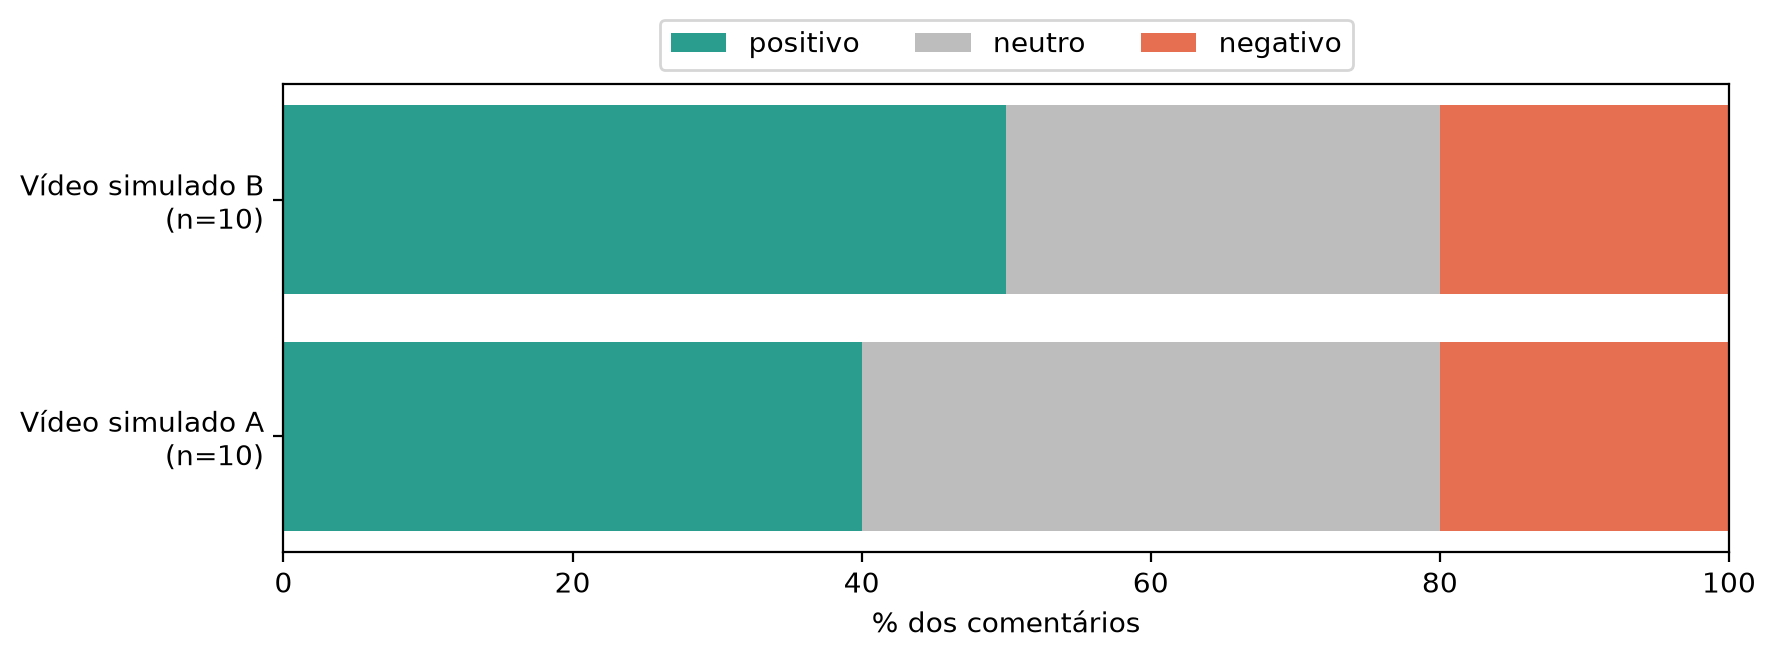

In [3]:
resumo = pd.read_csv(TABELAS / "resumo_por_video.csv")
tabela = pd.DataFrame({"vídeo": resumo["titulo"], "n": resumo["n"]})
for r in ["positivo", "neutro", "negativo"]:
    tabela[r] = [f"{p:.0f}% [{lo:.0f}–{hi:.0f}]" for p, lo, hi in
                 zip(resumo[f"pct_{r}"], resumo[f"ic_{r}_inf"], resumo[f"ic_{r}_sup"])]
tabela["score médio"] = resumo["score_medio"].round(2)
display(tabela)
display(Image(filename=ASSETS / "sentimento_por_video.png"))

## 3. Distribuição do score
Score = P(positivo) − P(negativo), de −1 a +1. Picos nas pontas indicam comentários polarizados; pico no meio, maioria neutra.

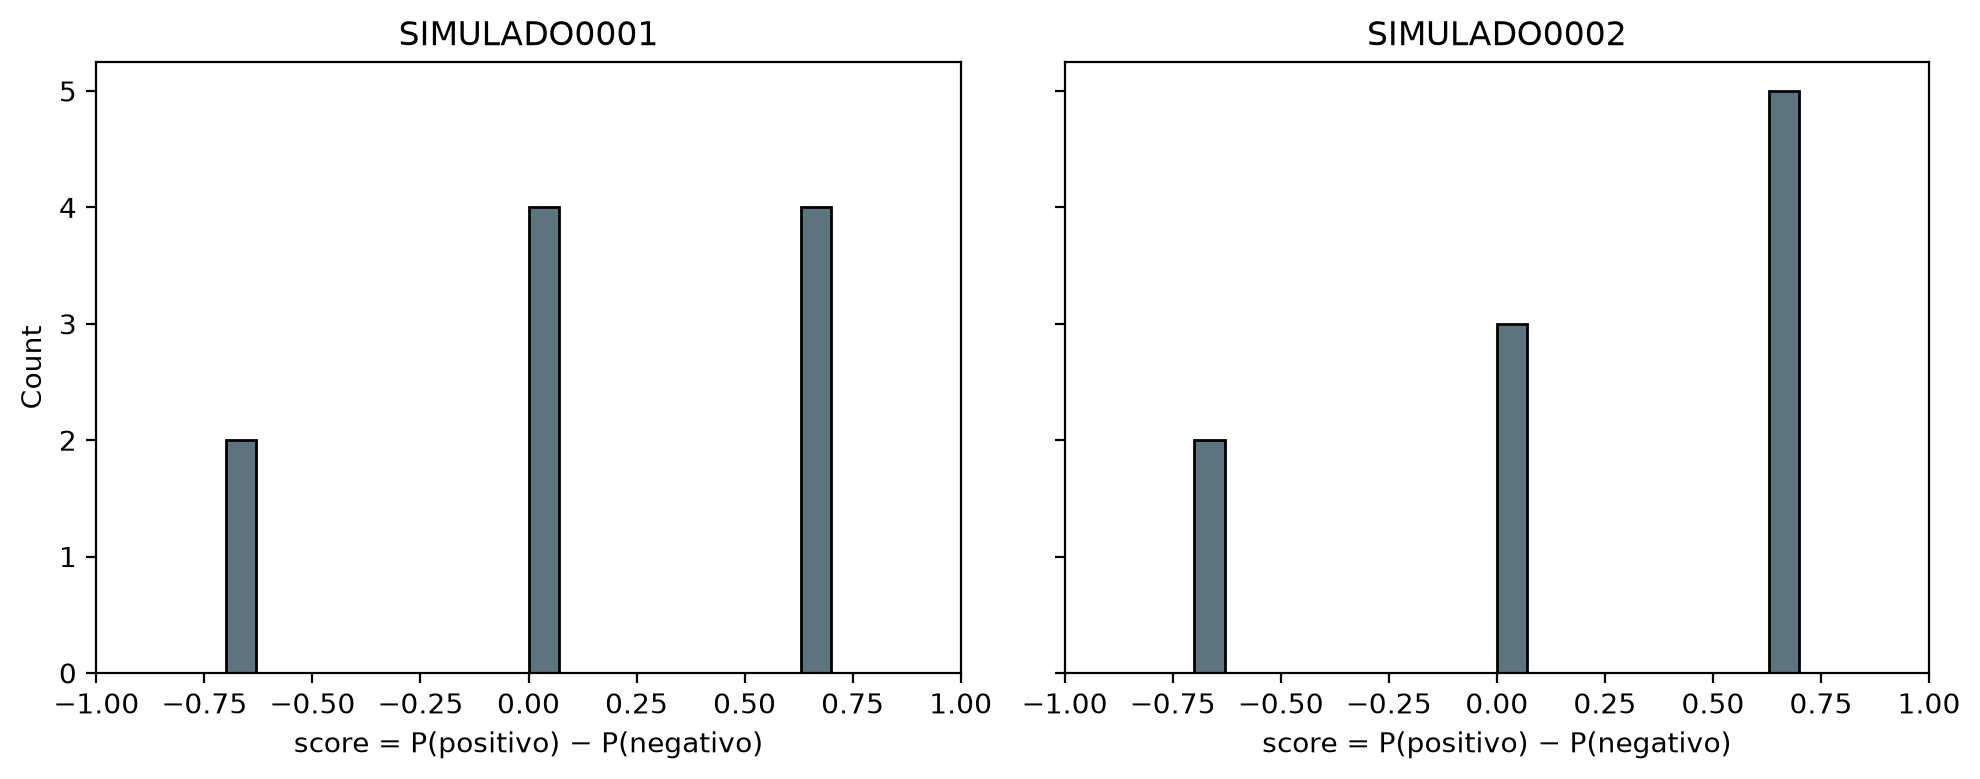

In [4]:
display(Image(filename=ASSETS / "distribuicao_score.png"))

## 4. Principais × respostas
As respostas costumam ter outro tom que os comentários principais.

In [5]:
tipo = pd.read_csv(TABELAS / "resumo_por_tipo.csv")
display(tipo.round(1))

,tipo,positivo,neutro,negativo,n
0,principal,53.3,33.3,13.3,15
1,resposta,20.0,40.0,40.0,5


## 5. Termos mais frequentes por sentimento
Lemas de substantivos, adjetivos, verbos e nomes próprios (spaCy). Mostra o **porquê** do resultado.

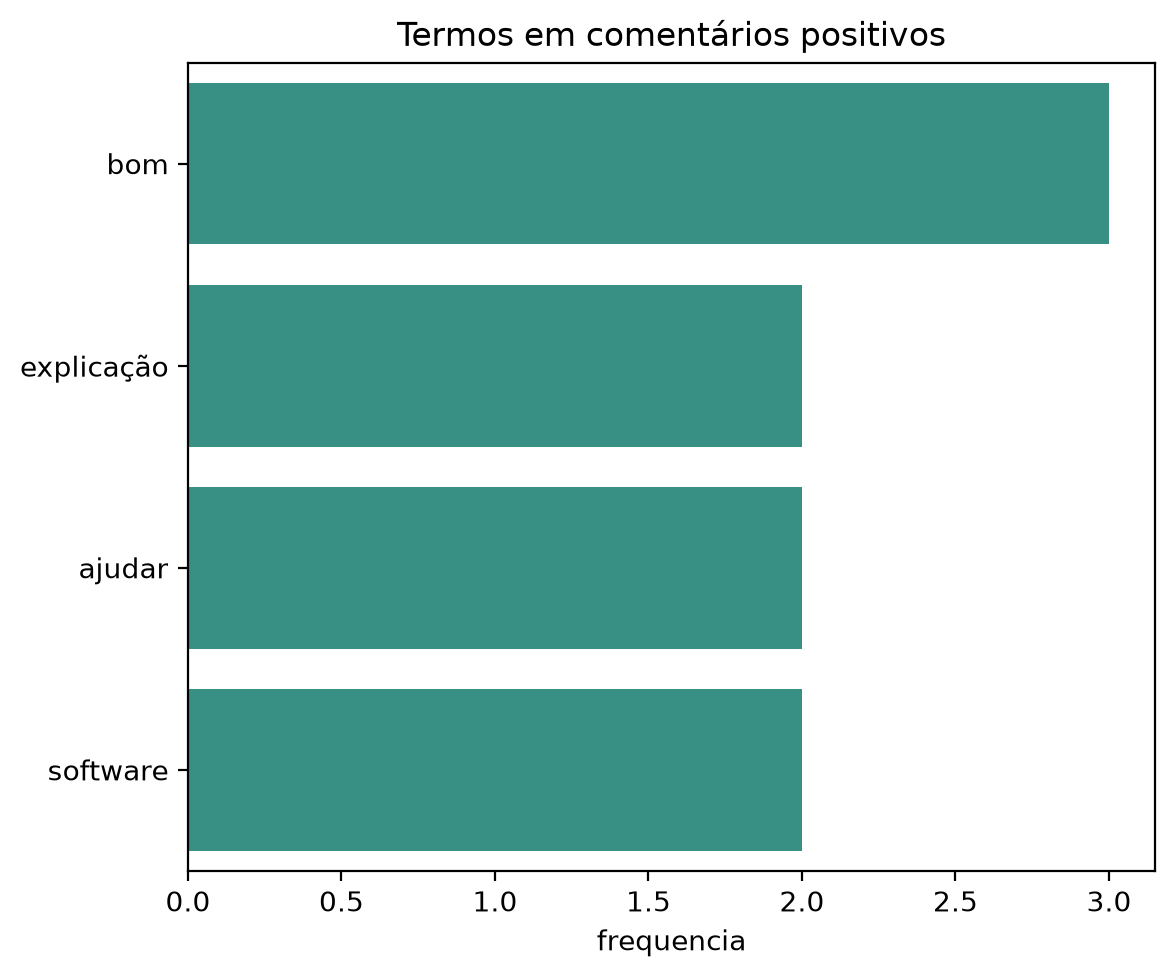

sentimento,positivo
posição,
1,bom
2,explicação
3,ajudar
4,software


In [6]:
display(Image(filename=ASSETS / "termos_por_sentimento.png"))
termos = pd.read_csv(TABELAS / "termos_por_sentimento.csv")
display(termos.pivot_table(index=termos.groupby("sentimento").cumcount() + 1, columns="sentimento",
                           values="termo", aggfunc="first").rename_axis("posição"))

## 6. Nuvem de palavras por vídeo

**Vídeo simulado A** (`SIMULADO0001`)

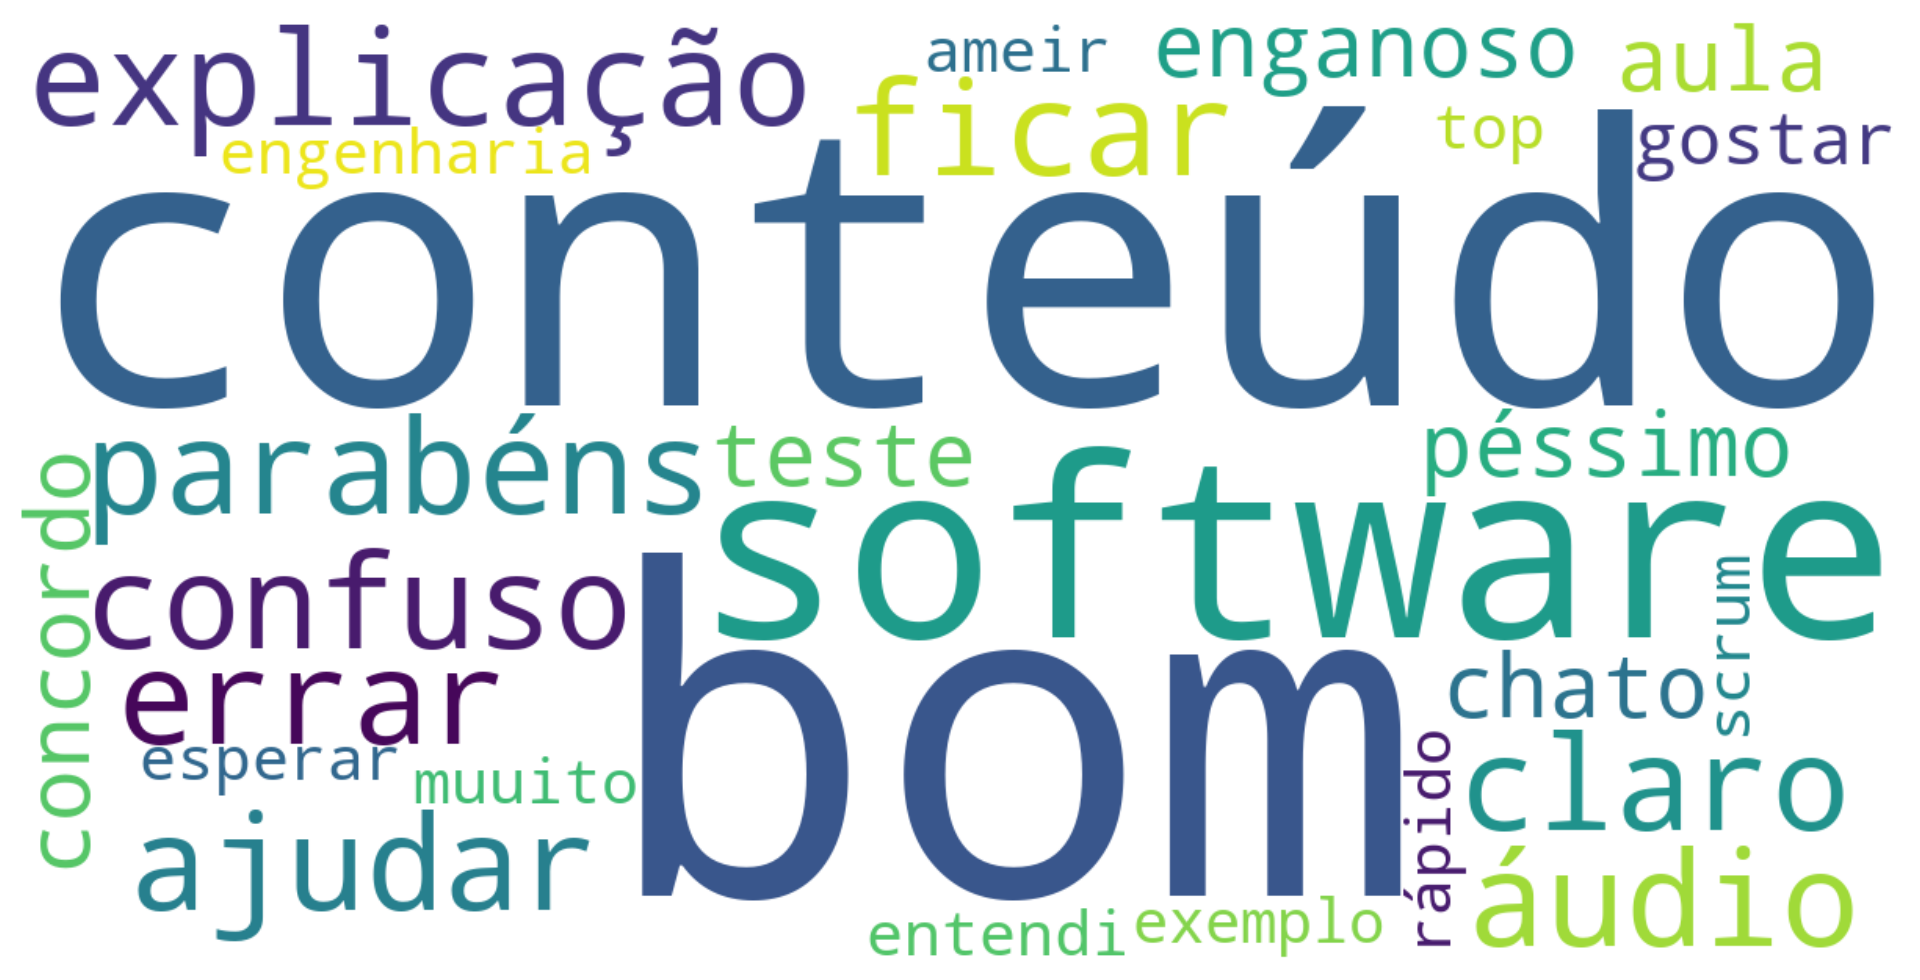

**Vídeo simulado B** (`SIMULADO0002`)

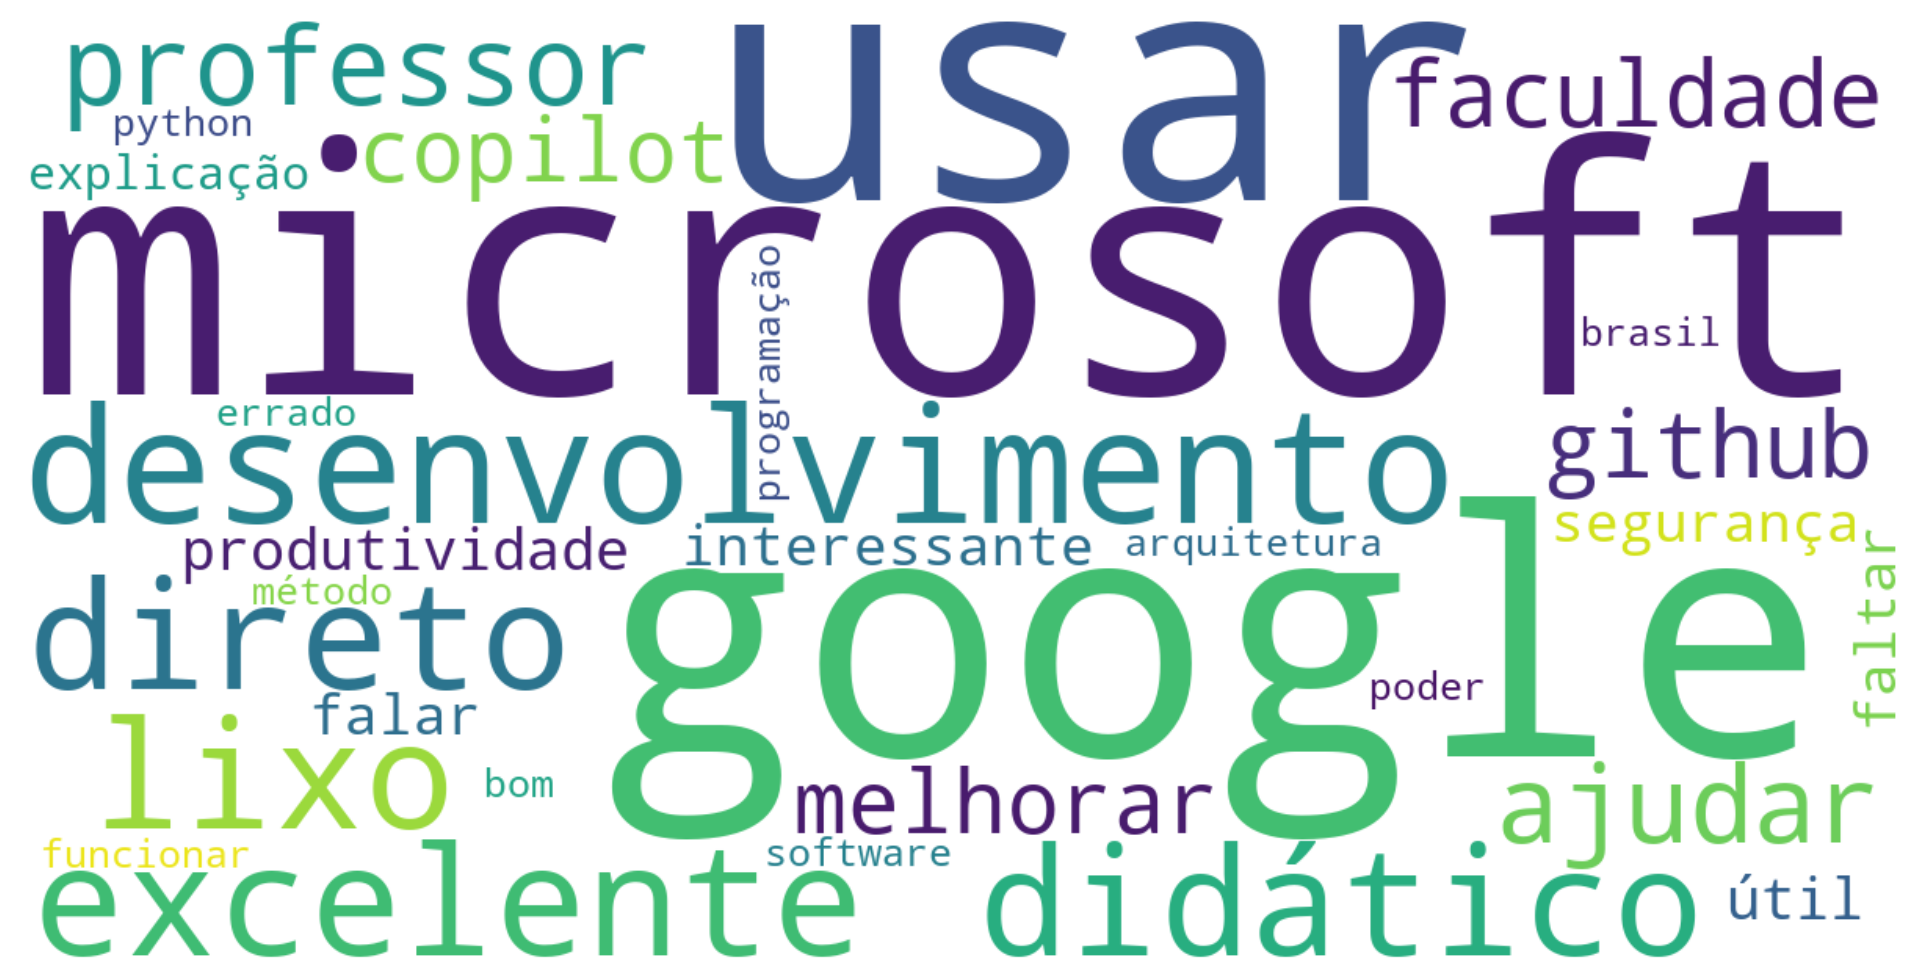

In [7]:
for caminho in sorted(ASSETS.glob("nuvem_*.png")):
    video = caminho.stem.replace("nuvem_", "")
    titulo = df.loc[df.video_id == video, "titulo_video"].iloc[0]
    display(Markdown(f"**{titulo}** (`{video}`)"))
    display(Image(filename=caminho, width=700))

## 7. Entidades e emojis

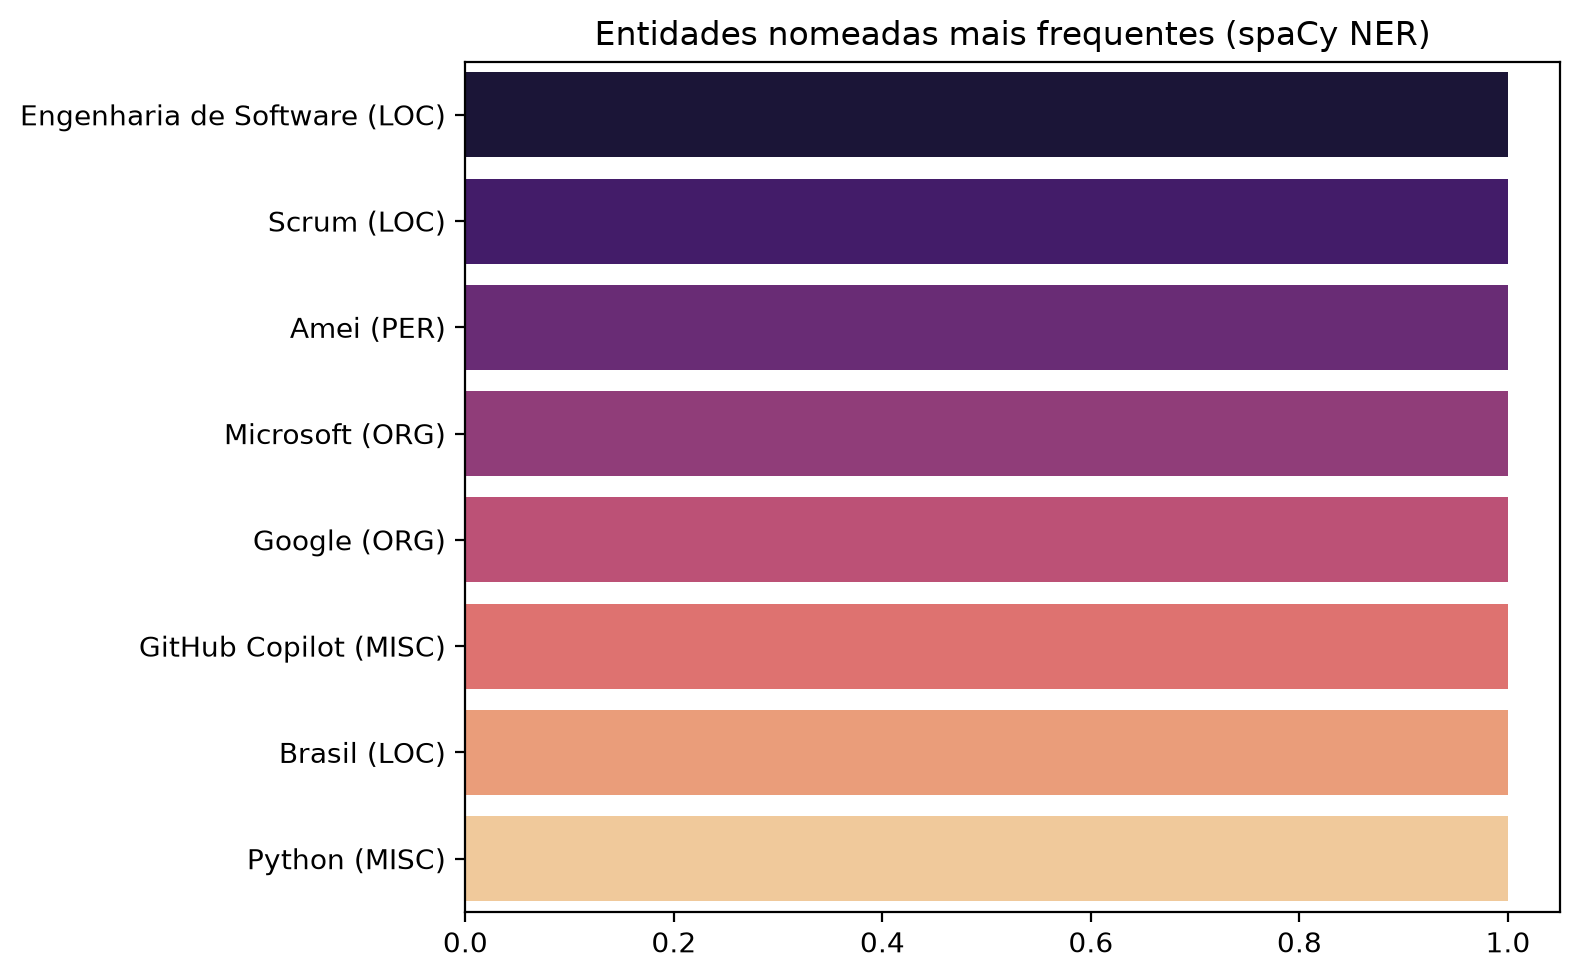

**Emojis mais usados**

,0,1,2,3
emoji,😂,👏,😡,🚀
frequencia,2,1,1,1


Risadas (kkk/haha/rs): 2 comentários | timestamps citados: 1 comentários


In [8]:
display(Image(filename=ASSETS / "entidades.png", width=600))
emojis = pd.read_csv(TABELAS / "top_emojis.csv")
display(Markdown("**Emojis mais usados**"))
display(emojis.T if not emojis.empty else "Nenhum emoji nos comentários classificados.")
print(f"Risadas (kkk/haha/rs): {int((df['n_risadas'] > 0).sum())} comentários | "
      f"timestamps citados: {int((df['n_timestamps'] > 0).sum())} comentários")

## 8. Exemplos reais
Gráfico convence mais com comentários de exemplo. Abaixo: os mais curtidos de cada sentimento.

In [9]:
def mostrar(sub, titulo):
    display(Markdown(f"### {titulo}"))
    for _, l in sub.iterrows():
        print(f"[{l.video_id} | {l.curtidas} curtidas | score {l.score:+.2f}]")
        print(textwrap.fill(l.texto, 110, initial_indent="  ", subsequent_indent="  "))
        print()

N = 3
for s in ["positivo", "negativo"]:
    mostrar(df[df.sentimento == s].nlargest(N, "curtidas"), f"Comentários {s}s mais curtidos")

### Comentários positivos mais curtidos

[SIMULADO0002 | 10 curtidas | score +0.70]
  Obrigado professor, ajudou muito na faculdade

[SIMULADO0002 | 9 curtidas | score +0.70]
  Boa explicação sobre arquitetura de software

[SIMULADO0001 | 7 curtidas | score +0.70]
  Ótimo vídeo kkkkk mas o áudio estava baixo



### Comentários negativos mais curtidos

[SIMULADO0001 | 10 curtidas | score -0.70]
  Péssimo, conteúdo enganoso e muito chato 😡

[SIMULADO0002 | 5 curtidas | score -0.70]
  Isso está errado, o método não funciona assim

[SIMULADO0001 | 3 curtidas | score -0.70]
  Aos 12:34 ele erra o exemplo, ficou confuso



## 9. Onde o modelo pode ter errado (para o slide de limitações)
Comentários em que o modelo ficou **menos confiante** (maior probabilidade ≤ 50%). Leia cada um e veja se a classificação faz sentido — ironia e gírias são os casos típicos.

In [10]:
df["confianca"] = df[["p_pos", "p_neu", "p_neg"]].max(axis=1)
duvidosos = df[df.texto_leve.str.split().str.len() >= 5].nsmallest(5, "confianca")
for _, l in duvidosos.iterrows():
    print(f"[{l.sentimento} | confiança {l.confianca:.0%}]")
    print(textwrap.fill(l.texto, 110, initial_indent="  ", subsequent_indent="  "))
    print()

[positivo | confiança 80%]
  Explicação muito clara, parabéns! Ajudou demais 👏

[positivo | confiança 80%]
  Ótimo vídeo kkkkk mas o áudio estava baixo

[negativo | confiança 80%]
  Aos 12:34 ele erra o exemplo, ficou confuso

[negativo | confiança 80%]
  Péssimo, conteúdo enganoso e muito chato 😡

[positivo | confiança 80%]
  @fulano concordo, melhor aula sobre testes de software



## 10. Limitações (resumo para o slide)
- Poucos comentários por vídeo → intervalos largos; não generalizar para "o público do YouTube".
- A amostra são os comentários mais recentes, com respostas na ordem da API.
- Ironia, sarcasmo e gírias de programação confundem o modelo; o `pt_core_news_sm` erra parte das entidades e lemas.
- Comentários em outros idiomas (texto longo) ficaram fora do recorte.